# Notebook template EDA segmentation d’images

Objectif : valider rapidement un dataset (images + masques) et le pipeline avant d’entraîner un modèle.

Ce notebook est volontairement générique :
- segmentation multi-classes (entiers dans les masques)
- support d’un `ignore_index` (ex: 255)
- palette optionnelle pour coloriser les masques

## Démarche du notebook (ordre d’exécution)

1) Configuration (chemins, classes 7 cat., ignore_index, échantillonnage).
2) Utilitaires de lecture (image RGB, masque, clé Cityscapes).
3) Construction des paires image/masque (Cityscapes).
4) Checks d’intégrité (manquants, tailles/modes).
5) Remapping labelIds -> trainIds -> 7 catégories (mapping officiel puis regroupement).
6) Visualisations (image/masque/overlay) avec palette fixe, void en noir.
7) Analyse des labels (valeurs uniques, fréquences, présence par image).
8) Vérification des splits (si colonne `split` présente).
9) Sanity check du redimensionnement (exemple avant/après, masque en nearest).
10) Baseline métriques NumPy (IoU/mIoU) si besoin.
11) Export rapide des stats (CSV).
12) (Optionnel) Log MLflow.



In [1]:
# Imports de base
from __future__ import annotations

import os
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Informations environnement
import sys, platform

print("Python:", sys.version)
print("Platform:", platform.platform())

# Optionnel: versions de libs
try:
    import matplotlib
    print("matplotlib:", matplotlib.__version__)
except Exception as e:
    print("matplotlib: NA", e)

try:
    import pandas
    print("pandas:", pandas.__version__)
except Exception as e:
    print("pandas: NA", e)

try:
    import numpy
    print("numpy:", numpy.__version__)
except Exception as e:
    print("numpy: NA", e)


Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
Platform: macOS-10.16-x86_64-i386-64bit
matplotlib: 3.8.4
pandas: 2.1.4
numpy: 1.26.4


## 1) Configuration

Tu peux fonctionner de deux façons :
- A) donner un dossier images + un dossier masques (mêmes noms de fichiers, extensions possiblement différentes)
- B) fournir un CSV déjà prêt avec colonnes `image_path` et `mask_path`

Le notebook essaie A en priorité, sinon B.


In [3]:
# Config EDA (chemins, classes, affichage)
@dataclass
class EDAConfig:
    images_dir: Optional[Path] = None
    masks_dir: Optional[Path] = None
    pairs_csv: Optional[Path] = None

    image_exts: Tuple[str, ...] = ('.png', '.jpg', '.jpeg', '.webp')
    mask_exts: Tuple[str, ...] = ('.png', '.tif', '.tiff')

    # Classes (Cityscapes 7 cat. par défaut)
    class_names: Optional[List[str]] = field(default_factory=lambda: ['flat','construction','object','nature','sky','human','vehicle'])
    ignore_index: Optional[int] = 255

    sample_n: int = 12
    random_seed: int = 42
    max_figsize: Tuple[int, int] = (12, 4)

cfg = EDAConfig(
    images_dir=Path('data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit'),
    masks_dir=Path('data/P8_Cityscapes_gtFine_trainvaltest/gtFine'),
    pairs_csv=None,
    ignore_index=255,
    sample_n=12,
    random_seed=42,
)

cfg


EDAConfig(images_dir=PosixPath('data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit'), masks_dir=PosixPath('data/P8_Cityscapes_gtFine_trainvaltest/gtFine'), pairs_csv=None, image_exts=('.png', '.jpg', '.jpeg', '.webp'), mask_exts=('.png', '.tif', '.tiff'), class_names=['flat', 'construction', 'object', 'nature', 'sky', 'human', 'vehicle'], ignore_index=255, sample_n=12, random_seed=42, max_figsize=(12, 4))

## 2) Utilitaires de lecture

Convention attendue :
- images en RGB
- masques en 1 canal (valeurs entières) ou en RGB indexé (palette) mais stocké en PNG ; dans ce cas PIL charge souvent en mode `P` ou `L`.


In [4]:
# Fonctions utilitaires de lecture image/masque
def read_image_rgb(path: Path) -> np.ndarray:
    img = Image.open(path).convert('RGB')
    return np.asarray(img, dtype=np.float32) / 255.0

def read_mask_ids(path: Path) -> np.ndarray:
    m = Image.open(path)
    if m.mode in ('P', 'L', 'I'):
        arr = np.asarray(m, dtype=np.int64)
        if arr.ndim == 3:
            arr = arr[..., 0].astype(np.int64)
        return arr
    return np.asarray(m.convert('L'), dtype=np.int64)

def pair_id_from_path(p: Path) -> str:
    parts = p.stem.split('_')
    if len(parts) >= 3:
        return '_'.join(parts[:3])
    return p.stem


## 3) Construction des paires (image, masque)

Résultat attendu : un DataFrame avec colonnes `id`, `image_path`, `mask_path`, `split` (optionnel).


In [5]:
# Construction des paires image/masque
def build_pairs_from_dirs(images_dir: Path, masks_dir: Path,
                          image_exts: Tuple[str, ...], mask_exts: Tuple[str, ...]) -> pd.DataFrame:
    images_dir = Path(images_dir)
    masks_dir = Path(masks_dir)

    img_paths = [p for p in images_dir.rglob('*') if p.suffix.lower() in image_exts]
    msk_paths = [p for p in masks_dir.rglob('*') if p.suffix.lower() in mask_exts]

    imgs = {pair_id_from_path(p): p for p in img_paths}
    msks = {pair_id_from_path(p): p for p in msk_paths}

    rows = []
    for _id in sorted(set(imgs.keys()) | set(msks.keys())):
        rows.append({
            'id': _id,
            'image_path': str(imgs.get(_id, '')),
            'mask_path': str(msks.get(_id, '')),
            'has_image': _id in imgs,
            'has_mask': _id in msks,
        })

    return pd.DataFrame(rows)

def load_pairs(cfg: EDAConfig) -> pd.DataFrame:
    if cfg.images_dir and cfg.masks_dir and cfg.images_dir.exists() and cfg.masks_dir.exists():
        df = build_pairs_from_dirs(cfg.images_dir, cfg.masks_dir, cfg.image_exts, cfg.mask_exts)
        df['split'] = 'unknown'
        return df

    if cfg.pairs_csv and Path(cfg.pairs_csv).exists():
        df = pd.read_csv(cfg.pairs_csv)
        if 'id' not in df.columns:
            df['id'] = df['image_path'].apply(lambda x: Path(x).stem)
        if 'split' not in df.columns:
            df['split'] = 'unknown'
        return df

    raise FileNotFoundError('Aucun dataset trouvé. Renseigne cfg.images_dir/cfg.masks_dir ou cfg.pairs_csv.')

pairs = load_pairs(cfg)
pairs.head()


,id,image_path,mask_path,has_image,has_mask,split
0,aachen_000000_000019,data/P8_Cityscapes_leftImg8bit_trainvaltest/le...,data/P8_Cityscapes_gtFine_trainvaltest/gtFine/...,True,True,unknown
1,aachen_000001_000019,data/P8_Cityscapes_leftImg8bit_trainvaltest/le...,data/P8_Cityscapes_gtFine_trainvaltest/gtFine/...,True,True,unknown
2,aachen_000002_000019,data/P8_Cityscapes_leftImg8bit_trainvaltest/le...,data/P8_Cityscapes_gtFine_trainvaltest/gtFine/...,True,True,unknown
3,aachen_000003_000019,data/P8_Cityscapes_leftImg8bit_trainvaltest/le...,data/P8_Cityscapes_gtFine_trainvaltest/gtFine/...,True,True,unknown
4,aachen_000004_000019,data/P8_Cityscapes_leftImg8bit_trainvaltest/le...,data/P8_Cityscapes_gtFine_trainvaltest/gtFine/...,True,True,unknown


## 4) Checks d’intégrité

On vérifie :
- images manquantes / masques manquants
- tailles image/masque cohérentes
- valeurs de masque plausibles (unique values, ignore_index)


In [6]:
# Checks d'intégrité (présence images/masques)
def quick_integrity_report(pairs: pd.DataFrame) -> pd.DataFrame:
    rep = {}
    rep['n_total'] = len(pairs)
    rep['n_missing_image'] = int((~pairs['has_image']).sum()) if 'has_image' in pairs else int(pairs['image_path'].eq('').sum())
    rep['n_missing_mask'] = int((~pairs['has_mask']).sum()) if 'has_mask' in pairs else int(pairs['mask_path'].eq('').sum())
    return pd.DataFrame([rep])

quick_integrity_report(pairs)


,n_total,n_missing_image,n_missing_mask
0,5000,0,0


In [7]:
# Détail des manquants (si besoin)
missing_images = pairs[pairs['image_path'].eq('')] if 'has_image' not in pairs else pairs[~pairs['has_image']]
missing_masks = pairs[pairs['mask_path'].eq('')] if 'has_mask' not in pairs else pairs[~pairs['has_mask']]

print('Images manquantes:', len(missing_images))
print('Masques manquants:', len(missing_masks))

missing_images.head()


Images manquantes: 0
Masques manquants: 0


,id,image_path,mask_path,has_image,has_mask,split


In [8]:
# Contrôle tailles/modes image vs masque (échantillon)
def check_shapes(pairs: pd.DataFrame, n: int = 200, seed: int = 42) -> pd.DataFrame:
    df = pairs.copy()
    df = df[(df['image_path'] != '') & (df['mask_path'] != '')]
    df = df.sample(min(n, len(df)), random_state=seed)

    rows = []
    for _, r in df.iterrows():
        ip = Path(r['image_path'])
        mp = Path(r['mask_path'])
        try:
            img = Image.open(ip)
            msk = Image.open(mp)
            rows.append({
                'id': r['id'],
                'img_size': img.size,
                'msk_size': msk.size,
                'same_size': img.size == msk.size,
                'img_mode': img.mode,
                'msk_mode': msk.mode,
            })
        except Exception as e:
            rows.append({'id': r['id'], 'error': str(e)})
    return pd.DataFrame(rows)

shape_checks = check_shapes(pairs, n=200, seed=cfg.random_seed)
shape_checks.head()


,id,img_size,msk_size,same_size,img_mode,msk_mode
0,cologne_000144_000019,"(2048, 1024)","(2048, 1024)",True,RGB,RGBA
1,hanover_000000_044622,"(2048, 1024)","(2048, 1024)",True,RGB,RGBA
2,jena_000016_000019,"(2048, 1024)","(2048, 1024)",True,RGB,I
3,bremen_000014_000019,"(2048, 1024)","(2048, 1024)",True,RGB,L
4,berlin_000531_000019,"(2048, 1024)","(2048, 1024)",True,RGB,I


### Interprétation du mode des masques

- `L` : masque 8-bit (0–255), OK pour des IDs de classes.
- `P` : masque indexé (palette), souvent OK pour des IDs; à convertir en 8-bit si besoin.
- `I` : masque 32-bit (entiers), peut contenir des IDs ou des instances; à reconvertir en 8-bit si ce sont des classes simples.
- `RGB/RGBA` : masque couleur (souvent un masque de visualisation, ex. `_color.png`), **pas** des IDs de classes.

Risques :
- Lire un masque `RGB/RGBA` comme des IDs donne des valeurs incohérentes (classes fausses).
- Les modes `I`/`P` doivent être convertis correctement en 8-bit si l’on attend des IDs de classes.
- Mélanger ces modes dans les stats/affichages peut fausser l’EDA (comptes de classes, palette).


In [9]:
# Paires avec tailles différentes (si any)
print('Paires avec tailles différentes:', int((shape_checks.get('same_size', True) == False).sum()))
shape_checks[shape_checks.get('same_size', True) == False].head()


Paires avec tailles différentes: 0


,id,img_size,msk_size,same_size,img_mode,msk_mode


## 5) Remapping labelIds -> trainIds -> 7 catégories

Les masques bruts Cityscapes sont en `labelIds` (0–33 + 255=ignore). On applique d’abord le mapping officiel `labelIds -> trainIds` (0–18 + 255), puis on regroupe en 7 catégories (flat, construction, object, nature, sky, human, vehicle) pour être cohérent avec ce qui est demandé.

In [10]:
# Mapping Cityscapes labelIds -> trainIds (0–18, 255=void)
_LABELID_TO_TRAINID = np.full(256, 255, dtype=np.uint8)
for label_id, train_id in [
    (0, 255), (1, 255), (2, 255), (3, 255), (4, 255), (5, 255), (6, 255),
    (7, 0), (8, 1), (9, 255), (10, 255),
    (11, 2), (12, 3), (13, 4), (14, 255), (15, 255), (16, 255),
    (17, 5), (18, 255),
    (19, 6), (20, 7),
    (21, 8), (22, 9),
    (23, 10),
    (24, 11), (25, 12),
    (26, 13), (27, 14), (28, 15),
    (29, 255), (30, 255),
    (31, 16), (32, 17), (33, 18),
    (255, 255),
]:
    _LABELID_TO_TRAINID[label_id] = np.uint8(train_id)

# trainIds -> 7 catégories (regroupement Cityscapes)
_TRAINID_TO_CAT = {
    0: 0, 1: 0,             # flat
    2: 1, 3: 1, 4: 1,       # construction
    5: 2, 6: 2, 7: 2,       # object
    8: 3, 9: 3,             # nature
    10: 4,                  # sky
    11: 5, 12: 5,           # human
    13: 6, 14: 6, 15: 6, 16: 6, 17: 6, 18: 6,  # vehicle
}

def label_ids_to_train_ids(mask: np.ndarray) -> np.ndarray:
    return _LABELID_TO_TRAINID[mask.astype(np.uint8)]

def remap_train_ids_to_categories(mask: np.ndarray) -> np.ndarray:
    out = np.full_like(mask, 255, dtype=np.uint8)
    for tid, cat in _TRAINID_TO_CAT.items():
        out[mask == tid] = np.uint8(cat)
    return out


In [11]:
# Palette fixe (7 classes) + affichage image/masque/overlay (void en noir)
PALETTE = np.array([
    [128, 64, 128],  # flat
    [70, 70, 70],    # construction
    [220, 220, 0],   # object
    [107, 142, 35],  # nature
    [70, 130, 180],  # sky
    [220, 20, 60],   # human
    [0, 0, 142],     # vehicle
], dtype=np.uint8)
VOID_COLOR = np.array([0, 0, 0], dtype=np.uint8)  # void en noir

def colorize_mask(mask_cat: np.ndarray, palette: np.ndarray, ignore_index: Optional[int]) -> np.ndarray:
    m = mask_cat.copy().astype(np.int64)
    rgb = np.zeros((m.shape[0], m.shape[1], 3), dtype=np.uint8)
    # Pixels valides
    valid = np.ones_like(m, dtype=bool)
    if ignore_index is not None:
        valid &= (m != ignore_index)
    valid &= (m >= 0) & (m < palette.shape[0])
    rgb[valid] = palette[m[valid]]
    # Void en noir
    if ignore_index is not None:
        rgb[m == ignore_index] = VOID_COLOR
    return rgb

def show_triplet(image: np.ndarray, mask_cat: np.ndarray, title: str = '', alpha: float = 0.35):
    mask_rgb = colorize_mask(mask_cat, PALETTE, cfg.ignore_index)
    # Overlay : alpha appliqué uniquement aux pixels non-void
    overlay = (image * 255).astype(np.uint8)
    if cfg.ignore_index is not None:
        valid = mask_cat != cfg.ignore_index
        overlay_f = overlay.astype(np.float32)
        overlay_f[valid] = overlay_f[valid] * (1 - alpha) + mask_rgb[valid].astype(np.float32) * alpha
        overlay = overlay_f.astype(np.uint8)
    else:
        overlay = (overlay.astype(np.float32) * (1 - alpha) + mask_rgb.astype(np.float32) * alpha).astype(np.uint8)

    fig, axs = plt.subplots(1, 3, figsize=cfg.max_figsize)
    fig.suptitle(title)
    axs[0].imshow(image); axs[0].set_title('Image')
    axs[1].imshow(mask_rgb); axs[1].set_title('Masque (7 classes + void)')
    axs[2].imshow(overlay); axs[2].set_title('Overlay')
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


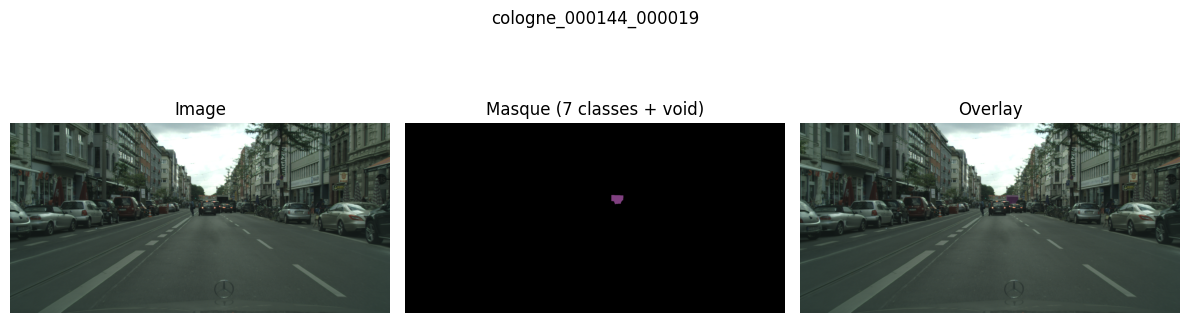

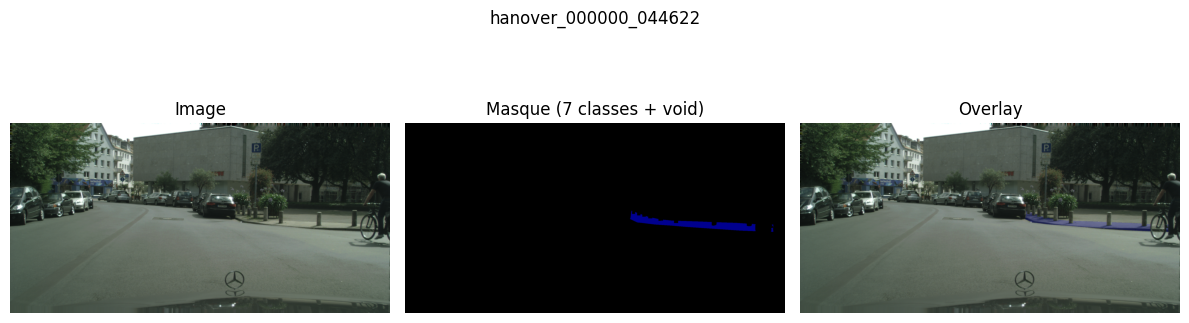

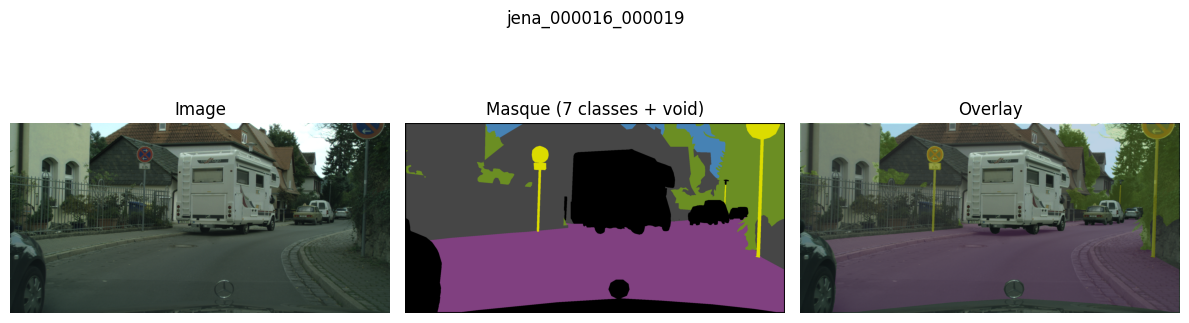

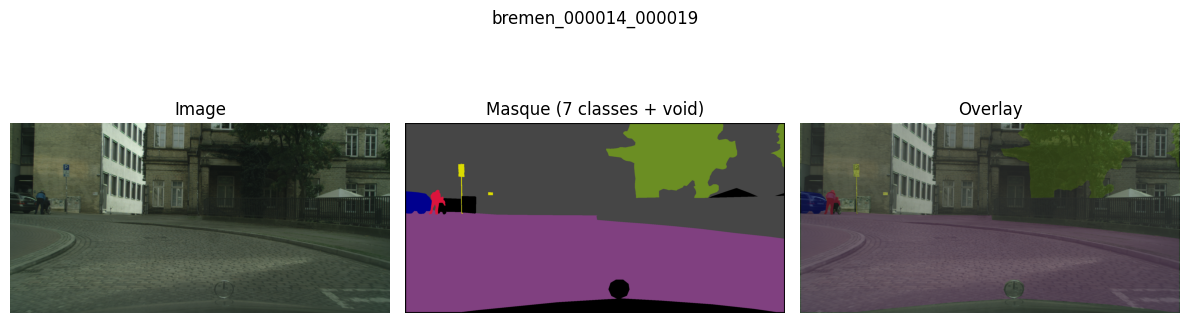

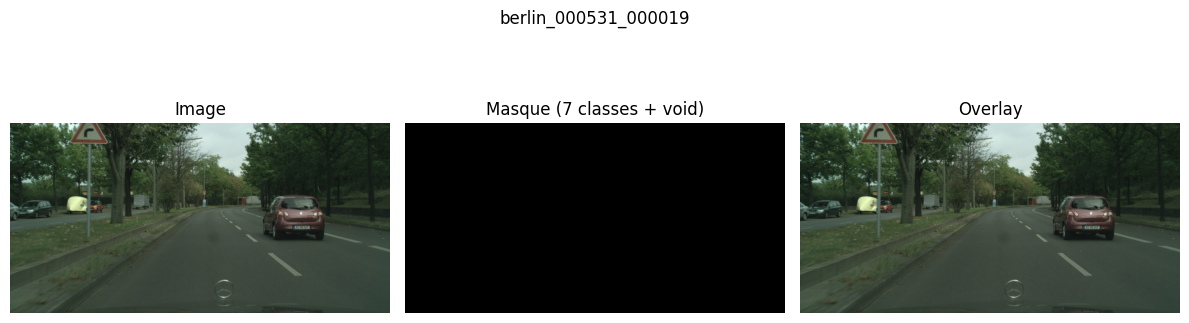

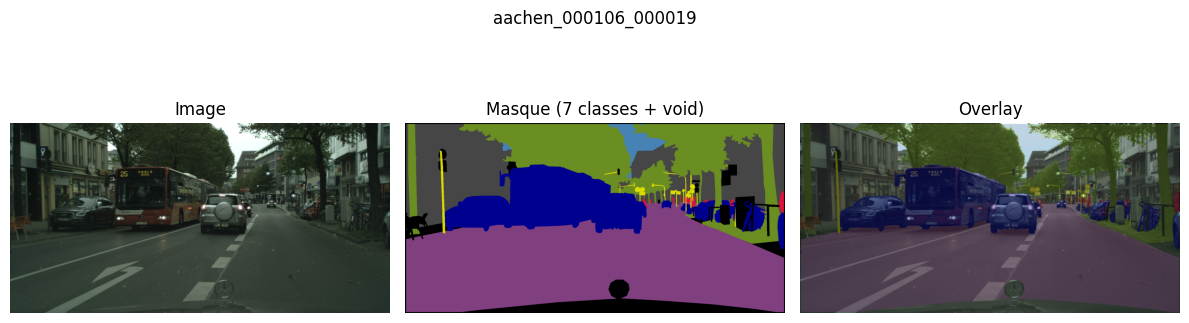

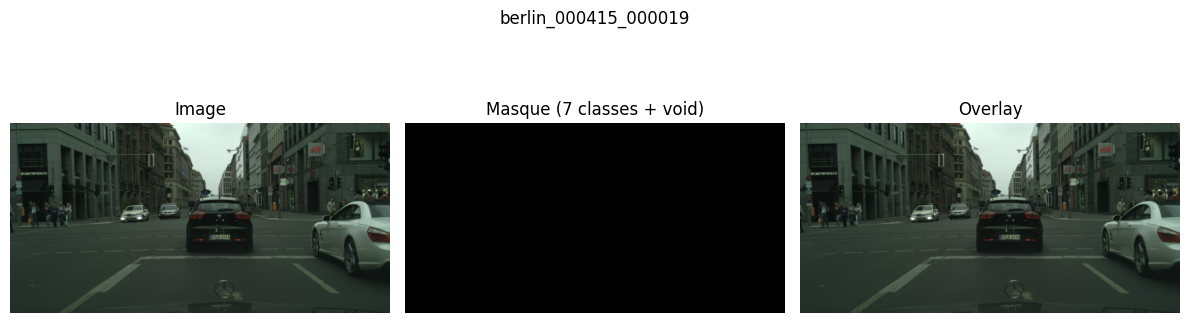

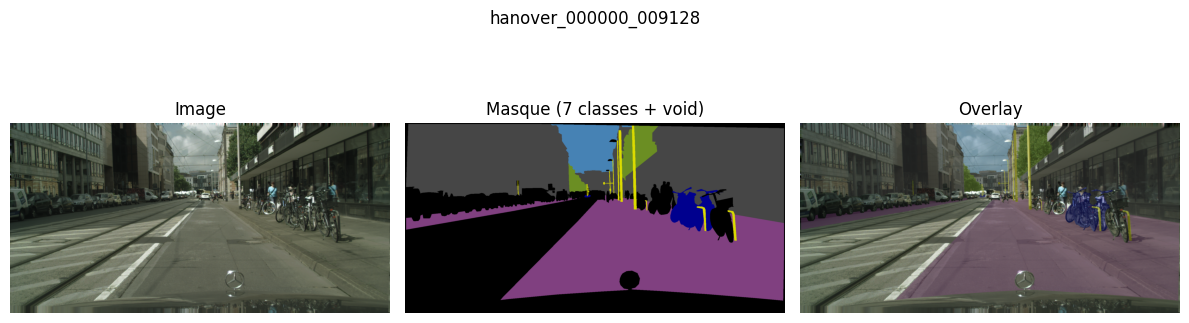

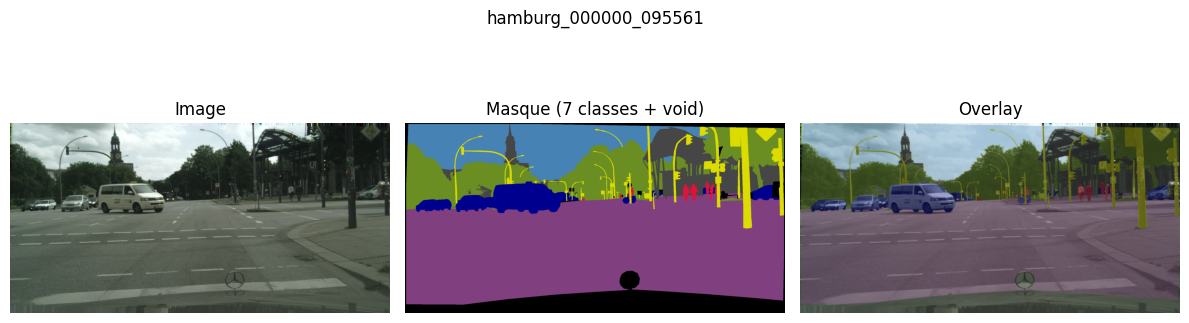

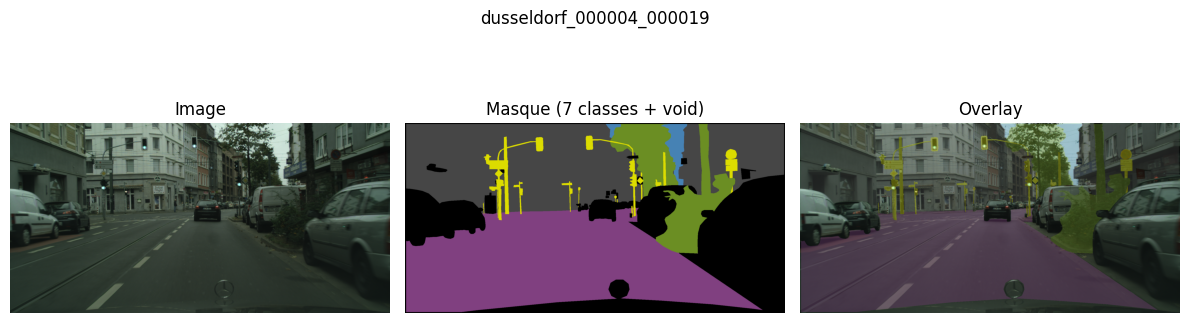

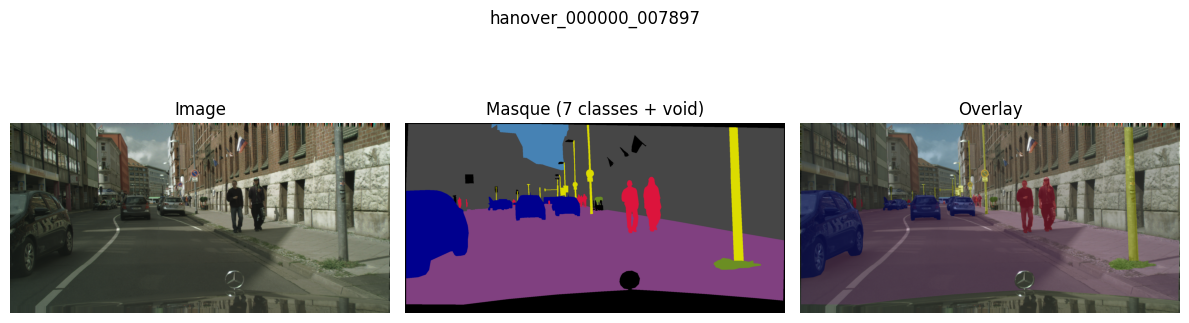

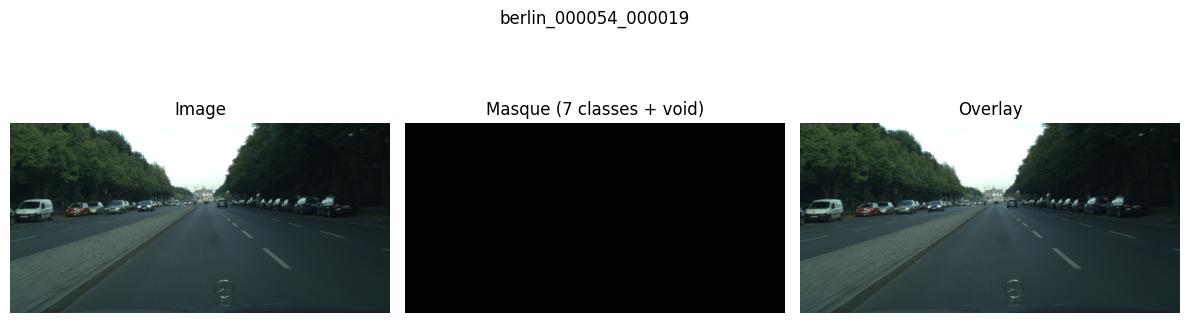

In [12]:
# Affichage d'un échantillon (labelIds -> trainIds -> 7 classes)
df_ok = pairs[(pairs['image_path'] != '') & (pairs['mask_path'] != '')].copy()
df_sample = df_ok.sample(min(cfg.sample_n, len(df_ok)), random_state=cfg.random_seed)

for _, r in df_sample.iterrows():
    img = read_image_rgb(Path(r['image_path']))
    label_ids = read_mask_ids(Path(r['mask_path'])).astype('uint8')
    train_ids = label_ids_to_train_ids(label_ids)  # labelIds -> trainIds
    cats = remap_train_ids_to_categories(train_ids)
    show_triplet(img, cats, title=r['id'], alpha=0.35)

## 6) Analyse des labels

On calcule :
- valeurs uniques globales
- fréquence pixels par classe
- présence par image (combien d’images contiennent la classe)


In [13]:
# Statistiques de labels (uniques, fréquences)
def scan_labels(pairs: pd.DataFrame, max_items: Optional[int] = None) -> Dict[str, object]:
    df = pairs[(pairs["mask_path"] != "")].copy()
    if max_items is not None:
        df = df.sample(min(max_items, len(df)), random_state=cfg.random_seed)

    unique_vals = set()
    pixel_counts: Dict[int, int] = {}
    image_presence: Dict[int, int] = {}

    for _, r in df.iterrows():
        mask = read_mask_ids(Path(r["mask_path"]))
        vals, counts = np.unique(mask, return_counts=True)
        for v, c in zip(vals.tolist(), counts.tolist()):
            unique_vals.add(int(v))
            pixel_counts[int(v)] = pixel_counts.get(int(v), 0) + int(c)
        for v in vals.tolist():
            image_presence[int(v)] = image_presence.get(int(v), 0) + 1

    out = {
        "n_masks_scanned": len(df),
        "unique_values": sorted(unique_vals),
        "pixel_counts": pixel_counts,
        "image_presence": image_presence,
    }
    return out

label_stats = scan_labels(pairs, max_items=None)
label_stats["n_masks_scanned"], label_stats["unique_values"][:30]


(5000,
 [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29])

In [14]:
# Fréquences pixels
pix = pd.Series(label_stats["pixel_counts"]).sort_index()
if cfg.ignore_index is not None and cfg.ignore_index in pix.index:
    pix_no_ign = pix.drop(cfg.ignore_index)
else:
    pix_no_ign = pix

pix_df = pd.DataFrame({
    "pixel_count": pix_no_ign,
    "pixel_pct": 100.0 * pix_no_ign / pix_no_ign.sum()
}).sort_values("pixel_count", ascending=False)

pix_df.head(20)


,pixel_count,pixel_pct
0,3254663286,31.038888
7,1611099245,15.364640
11,986152496,9.404683
90,770581722,7.348840
21,703539315,6.709474
70,475489052,4.534617
119,335112681,3.195884
1,323285644,3.083092
8,268107441,2.556872
23,171237295,1.633046


### Distribution agrégée (7 catégories Cityscapes)

Pour Cityscapes, on peut regrouper les `labelIds` (0-33) en 7 catégories via `fvt.data.labels`. Cela reflète ce que verra le modèle (pipeline FVT).

In [15]:
from fvt.data.labels import label_ids_to_train_ids, remap_train_ids_to_categories, VOID_ID

def category_distribution(df_masks, max_items=500):
    df = df_masks.copy()
    if max_items is not None:
        df = df.sample(min(max_items, len(df)), random_state=cfg.random_seed)
    counts = {i: 0 for i in range(7)}
    counts['void'] = 0
    for _, r in df.iterrows():
        m = read_mask_ids(Path(r['mask_path'])).astype('uint8')
        train_ids = label_ids_to_train_ids(m)
        cats = remap_train_ids_to_categories(train_ids)
        vals, cts = np.unique(cats, return_counts=True)
        for v, c in zip(vals.tolist(), cts.tolist()):
            if v == VOID_ID:
                counts['void'] += int(c)
            elif 0 <= v <= 6:
                counts[int(v)] += int(c)
    return pd.Series(counts)

pix7 = category_distribution(df_ok, max_items=400)
pix7_pct = 100.0 * pix7 / pix7.sum()
display(pd.DataFrame({'pixel_count': pix7, 'pixel_pct': pix7_pct}).sort_index())


TypeError: '<' not supported between instances of 'str' and 'int'

## 7) Analyse des labels

On calcule :
- valeurs uniques globales
- fréquence pixels par classe
- présence par image (combien d’images contiennent la classe)


In [ ]:
# Fonctions utilitaires de lecture image/masque
VOID_THRESH = 0.99
MAX_SCAN_VOID = 400  # échantillon pour aller vite

def void_fraction(mask_path: Path) -> float:
    m = read_mask_ids(mask_path).astype('int64')
    if cfg.ignore_index is None:
        return 0.0
    return float((m == cfg.ignore_index).sum() / (m.size + 1e-12))

df_void = df_ok.sample(min(MAX_SCAN_VOID, len(df_ok)), random_state=cfg.random_seed).copy()
df_void['void_frac'] = df_void['mask_path'].apply(lambda p: void_fraction(Path(p)))
sus_void = df_void[df_void['void_frac'] >= VOID_THRESH]

print(f'Analysés: {len(df_void)} masques (échantillon), suspects void: {len(sus_void)}')
display(sus_void[['id','void_frac']].head())

# Visualisation de quelques masques suspects (remappés en 7 catégories pour rester cohérent avec l'apprentissage)
for _, r in sus_void.head(3).iterrows():
    img = read_image_rgb(Path(r['image_path']))
    m = read_mask_ids(Path(r['mask_path'])).astype('uint8')
    train_ids = label_ids_to_train_ids(m)
    cats = remap_train_ids_to_categories(train_ids)
    title = f"{r['id']} (void={r['void_frac']:.3f})"
    show_triplet(img, cats, title=title, alpha=0.45)


In [ ]:
# Graph fréquence pixels (top K)
top_k = 20 if len(pix_df) > 20 else len(pix_df)
ax = pix_df.head(top_k).sort_index()["pixel_pct"].plot(kind="bar", figsize=(12, 4))
ax.set_ylabel("Pourcentage pixels (%)")
ax.set_title("Distribution pixels par label (top K, trié par id)")
plt.tight_layout()
plt.show()


In [ ]:
# Présence par image
pres = pd.Series(label_stats["image_presence"]).sort_index()
if cfg.ignore_index is not None and cfg.ignore_index in pres.index:
    pres_no_ign = pres.drop(cfg.ignore_index)
else:
    pres_no_ign = pres

pres_df = pd.DataFrame({
    "n_images": pres_no_ign,
    "pct_images": 100.0 * pres_no_ign / pres_no_ign.max()
}).sort_values("n_images", ascending=False)

pres_df.head(20)


## 7) Vérification des splits (si tu as train/val/test)

Si tu as une colonne `split`, on compare la distribution de présence de classes entre splits.


In [ ]:
# Statistiques de labels (uniques, fréquences)
def scan_labels_by_split(pairs: pd.DataFrame, split_col: str = "split") -> pd.DataFrame:
    if split_col not in pairs.columns:
        raise ValueError(f"Colonne {split_col} absente.")

    rows = []
    for split, df in pairs.groupby(split_col):
        stats = scan_labels(df, max_items=None)
        pres = stats["image_presence"]
        for label, nimg in pres.items():
            if cfg.ignore_index is not None and label == cfg.ignore_index:
                continue
            rows.append({"split": split, "label": label, "n_images": nimg})
    out = pd.DataFrame(rows)
    return out

if "split" in pairs.columns and pairs["split"].nunique() > 1:
    split_df = scan_labels_by_split(pairs)
    display(split_df.head())
else:
    print("Pas de split exploitable (colonne 'split' absente ou unique).")


## 8) Sanity check du redimensionnement

Si tu redimensionnes pendant l’entraînement, vérifie :
- image: bilinear ok
- masque: nearest-neighbor obligatoire

Cette cellule te montre une paire avant/après resize.


In [ ]:
# Sanity check du redimensionnement (image bilinear / masque nearest remappé)
def resize_image_and_mask(image: np.ndarray, mask: np.ndarray, size_hw: Tuple[int, int]) -> Tuple[np.ndarray, np.ndarray]:
    H, W = size_hw
    img_pil = Image.fromarray((image * 255).astype(np.uint8))
    msk_pil = Image.fromarray(mask.astype(np.uint8), mode='L')
    img_res = img_pil.resize((W, H), resample=Image.BILINEAR)
    msk_res = msk_pil.resize((W, H), resample=Image.NEAREST)
    img_res = np.asarray(img_res, dtype=np.float32) / 255.0
    msk_res = np.asarray(msk_res, dtype=np.int64)
    return img_res, msk_res

row = df_sample.iloc[0]
img = read_image_rgb(Path(row['image_path']))
label_ids = read_mask_ids(Path(row['mask_path'])).astype('uint8')
train_ids = label_ids_to_train_ids(label_ids)
cats = remap_train_ids_to_categories(train_ids)

show_triplet(img, cats, title=f"{row['id']} (original)", alpha=0.45)
img_r, msk_r = resize_image_and_mask(img, cats, size_hw=(256, 512))
show_triplet(img_r, msk_r, title=f"{row['id']} (resized 256x512)", alpha=0.45)


## 9) Baseline métriques (IoU, mIoU) en NumPy

Utile pour :
- vérifier que ton calcul de métrique est cohérent
- comparer une baseline naïve (classe majoritaire) et détecter une métrique "cassée"


In [ ]:
def confusion_matrix_flat(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int, ignore_index: Optional[int] = None) -> np.ndarray:
    yt = y_true.reshape(-1).astype(np.int64)
    yp = y_pred.reshape(-1).astype(np.int64)

    if ignore_index is not None:
        keep = yt != ignore_index
        yt, yp = yt[keep], yp[keep]

    yt = np.clip(yt, 0, num_classes - 1)
    yp = np.clip(yp, 0, num_classes - 1)

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    idx = num_classes * yt + yp
    binc = np.bincount(idx, minlength=num_classes * num_classes)
    cm = binc.reshape((num_classes, num_classes))
    return cm

def iou_per_class_from_cm(cm: np.ndarray) -> np.ndarray:
    # IoU_k = TP / (TP + FP + FN)
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0).astype(np.float64) - tp
    fn = cm.sum(axis=1).astype(np.float64) - tp
    denom = tp + fp + fn + 1e-12
    return tp / denom

def miou_from_cm(cm: np.ndarray) -> float:
    ious = iou_per_class_from_cm(cm)
    return float(np.nanmean(ious))

def pixel_accuracy_from_cm(cm: np.ndarray) -> float:
    return float(np.diag(cm).sum() / (cm.sum() + 1e-12))


In [ ]:
# Choix du nombre de classes:
# Si class_names est défini, on prend len(class_names)
# Sinon, on infère sur les labels présents (hors ignore_index) et on prend max+1
def infer_num_classes(pairs: pd.DataFrame) -> int:
    vals = label_stats["unique_values"]
    if cfg.ignore_index is not None:
        vals = [v for v in vals if v != cfg.ignore_index]
    if cfg.class_names is not None:
        return len(cfg.class_names)
    if len(vals) == 0:
        raise ValueError("Impossible d'inférer le nombre de classes (aucune valeur dans les masques).")
    return int(max(vals) + 1)

NUM_CLASSES = infer_num_classes(pairs)
print("NUM_CLASSES =", NUM_CLASSES)


In [ ]:
# Baseline naïve: prédire toujours la classe la plus fréquente en pixels (hors ignore_index)
major_class = int(pix_no_ign.idxmax()) if len(pix_no_ign) else 0
print("Classe majoritaire (hors ignore):", major_class)

# Evaluation sur un échantillon
eval_n = min(30, len(df_ok))
df_eval = df_ok.sample(eval_n, random_state=cfg.random_seed)

cm_total = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for _, r in df_eval.iterrows():
    m = read_mask_ids(Path(r["mask_path"]))
    y_pred = np.full_like(m, fill_value=major_class)
    cm = confusion_matrix_flat(m, y_pred, num_classes=NUM_CLASSES, ignore_index=cfg.ignore_index)
    cm_total += cm

print("pixel_accuracy:", pixel_accuracy_from_cm(cm_total))
print("mIoU:", miou_from_cm(cm_total))

ious = iou_per_class_from_cm(cm_total)
pd.DataFrame({"class_id": np.arange(NUM_CLASSES), "IoU": ious}).sort_values("IoU", ascending=False).head(10)


## 10) Export rapide des stats (CSV)

Tu peux sauvegarder :
- la table pixel par classe
- la table présence par classe
pour les réutiliser dans un rapport.


In [ ]:
out_dir = Path("eda_outputs")
out_dir.mkdir(parents=True, exist_ok=True)

pix_df.to_csv(out_dir / "pixel_distribution_by_label.csv", index=True)
pres_df.to_csv(out_dir / "presence_by_label.csv", index=True)

print("Ecrit:", out_dir / "pixel_distribution_by_label.csv")
print("Ecrit:", out_dir / "presence_by_label.csv")


## 11) (Optionnel) Log MLflow

Si MLflow est installé, tu peux logger quelques artefacts de ce notebook.


In [ ]:
try:
    import mlflow

    mlflow.set_experiment("EDA_segmentation_images")

    with mlflow.start_run(run_name="eda_dataset_check"):
        # Paramètres clés
        mlflow.log_param("n_total_pairs", int(len(pairs)))
        mlflow.log_param("ignore_index", cfg.ignore_index if cfg.ignore_index is not None else "None")
        mlflow.log_param("num_classes", int(NUM_CLASSES))

        # Artefacts
        mlflow.log_artifact(str(out_dir / "pixel_distribution_by_label.csv"))
        mlflow.log_artifact(str(out_dir / "presence_by_label.csv"))

        print("MLflow: run loggé")
except Exception as e:
    print("MLflow indisponible ou non configuré:", e)


In [ ]:
# Affichage d'un échantillon remappé (labelIds -> trainIds -> 7 classes)
df_ok = pairs[(pairs['image_path'] != '') & (pairs['mask_path'] != '')].copy()
df_sample = df_ok.sample(min(cfg.sample_n, len(df_ok)), random_seed=cfg.random_seed)

for _, r in df_sample.iterrows():
    img = read_image_rgb(Path(r['image_path']))
    label_ids = read_mask_ids(Path(r['mask_path'])).astype('uint8')
    train_ids = label_ids_to_train_ids(label_ids)
    cats = remap_train_ids_to_categories(train_ids)
    show_triplet(img, cats, title=r['id'], alpha=0.35)